In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os
import warnings

warnings.filterwarnings("ignore")
os.makedirs("charts", exist_ok=True)

# Load cleaned NAV data
df = pd.read_csv("data/processed/nav_history_clean.csv", parse_dates=["date"])
df = df.sort_values(["scheme_label", "date"]).reset_index(drop=True)

print("Shape:", df.shape)
print("Schemes:", df["scheme_label"].unique())
print("Date range:", df["date"].min(), "to", df["date"].max())

Shape: (5509, 6)
Schemes: ['Axis_Bluechip' 'HDFC_Top100' 'ICICI_Bluechip' 'Kotak_Bluechip'
 'Nippon_LargeCap']
Date range: 2022-01-03 00:00:00 to 2026-06-25 00:00:00


=== Daily Return Statistics ===

                  count    mean     std     min     25%     50%     75%  \
scheme_label                                                              
Axis_Bluechip    1083.0  0.0003  0.0002 -0.0015  0.0002  0.0002  0.0004   
HDFC_Top100      1110.0  0.0005  0.0087 -0.0458 -0.0031  0.0011  0.0052   
ICICI_Bluechip   1109.0  0.0003  0.0090 -0.0461 -0.0041  0.0006  0.0053   
Kotak_Bluechip   1101.0  0.0007  0.0112 -0.0878 -0.0047  0.0013  0.0073   
Nippon_LargeCap  1101.0  0.0006  0.0089 -0.0662 -0.0035  0.0010  0.0055   

                    max  
scheme_label             
Axis_Bluechip    0.0017  
HDFC_Top100      0.0341  
ICICI_Bluechip   0.0392  
Kotak_Bluechip   0.0415  
Nippon_LargeCap  0.0378  


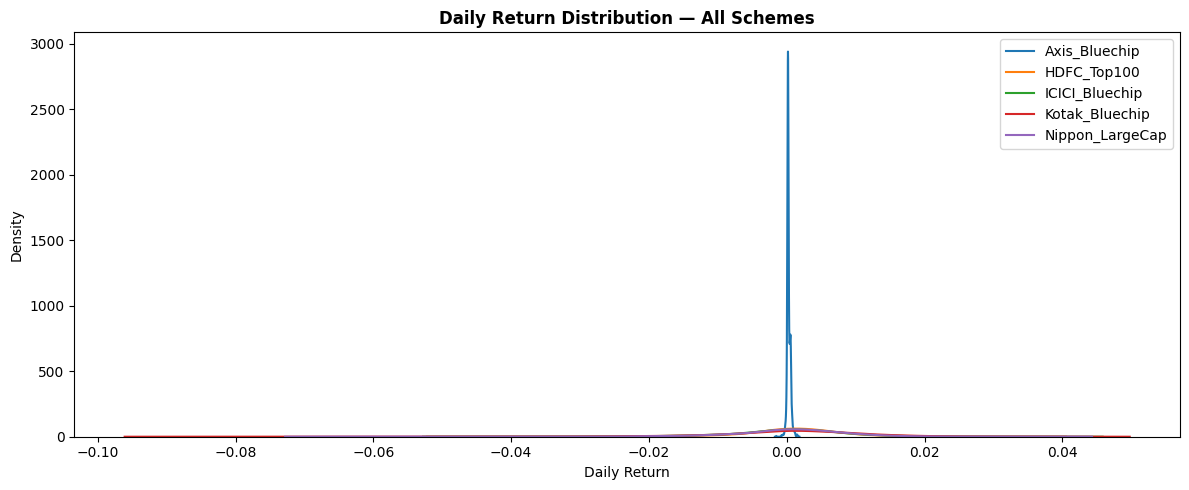

✅ Daily returns computed.


In [2]:
# TASK 1: Compute daily returns for all schemes

df["daily_return"] = df.groupby("scheme_label")["nav"].pct_change()

# Validate — print stats per scheme
print("=== Daily Return Statistics ===\n")
print(df.groupby("scheme_label")["daily_return"].describe().round(4))

# Plot distribution
plt.figure(figsize=(12, 5))
for scheme in df["scheme_label"].unique():
    data = df[df["scheme_label"] == scheme]["daily_return"].dropna()
    sns.kdeplot(data, label=scheme)

plt.title("Daily Return Distribution — All Schemes", fontweight="bold")
plt.xlabel("Daily Return")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.savefig("charts/daily_return_distribution.png", dpi=150)
plt.show()
print("✅ Daily returns computed.")

=== CAGR Comparison Table ===
         scheme  CAGR_1yr_%  CAGR_3yr_%  CAGR_full_%
  Axis_Bluechip        6.36        7.40         6.90
    HDFC_Top100        3.28       14.14        13.04
 ICICI_Bluechip       -0.91       11.69         6.31
 Kotak_Bluechip        2.23       17.46        16.37
Nippon_LargeCap       -0.05       15.46        14.88


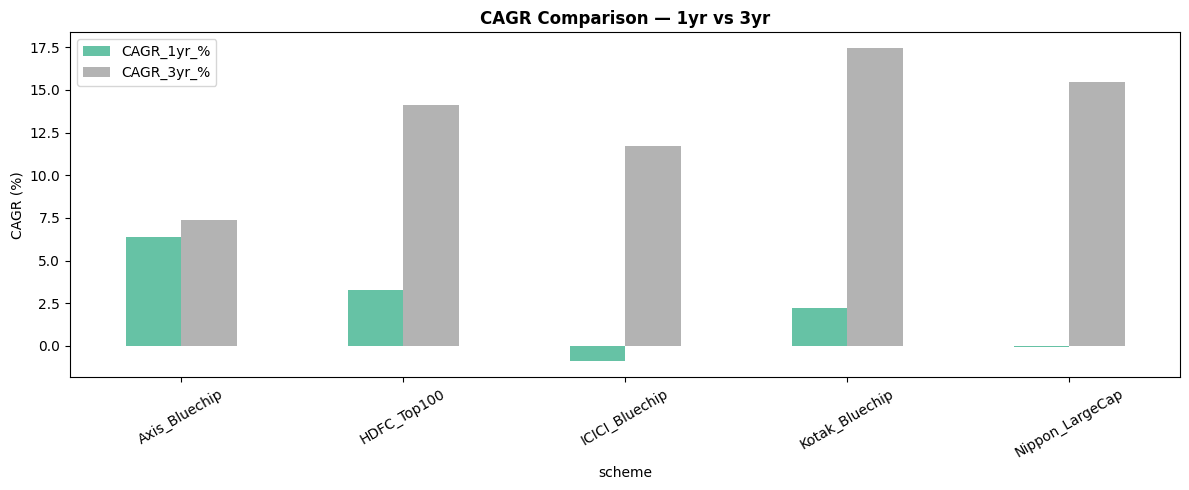

✅ CAGR computed.


In [3]:
# TASK 2: CAGR for 1yr, 3yr, and full period

def compute_cagr(group, years):
    end_date = group["date"].max()
    start_date = end_date - pd.DateOffset(years=years)
    subset = group[group["date"] >= start_date]
    if len(subset) < 2:
        return np.nan
    nav_start = subset.iloc[0]["nav"]
    nav_end = subset.iloc[-1]["nav"]
    actual_years = (subset.iloc[-1]["date"] - subset.iloc[0]["date"]).days / 365.25
    if actual_years <= 0 or nav_start <= 0:
        return np.nan
    return (nav_end / nav_start) ** (1 / actual_years) - 1

cagr_records = []
for scheme, group in df.groupby("scheme_label"):
    cagr_records.append({
        "scheme": scheme,
        "CAGR_1yr_%": round(compute_cagr(group, 1) * 100, 2),
        "CAGR_3yr_%": round(compute_cagr(group, 3) * 100, 2),
        "CAGR_full_%": round(compute_cagr(group, 10) * 100, 2),
    })

cagr_df = pd.DataFrame(cagr_records)
print("=== CAGR Comparison Table ===")
print(cagr_df.to_string(index=False))

# Bar chart
cagr_df.set_index("scheme")[["CAGR_1yr_%", "CAGR_3yr_%"]].plot(
    kind="bar", figsize=(12, 5), colormap="Set2"
)
plt.title("CAGR Comparison — 1yr vs 3yr", fontweight="bold")
plt.ylabel("CAGR (%)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("charts/cagr_comparison.png", dpi=150)
plt.show()
print("✅ CAGR computed.")

=== Sharpe & Sortino Ranking ===
         scheme  Sharpe_Ratio  Sortino_Ratio  Ann_Return_%  Ann_Volatility_%
  Axis_Bluechip         1.125          1.112          6.94              0.39
Nippon_LargeCap         0.618          0.795         15.20             14.08
 Kotak_Bluechip         0.598          0.736         17.12             17.76
    HDFC_Top100         0.501          0.611         13.41             13.78
 ICICI_Bluechip         0.052          0.069          7.25             14.32


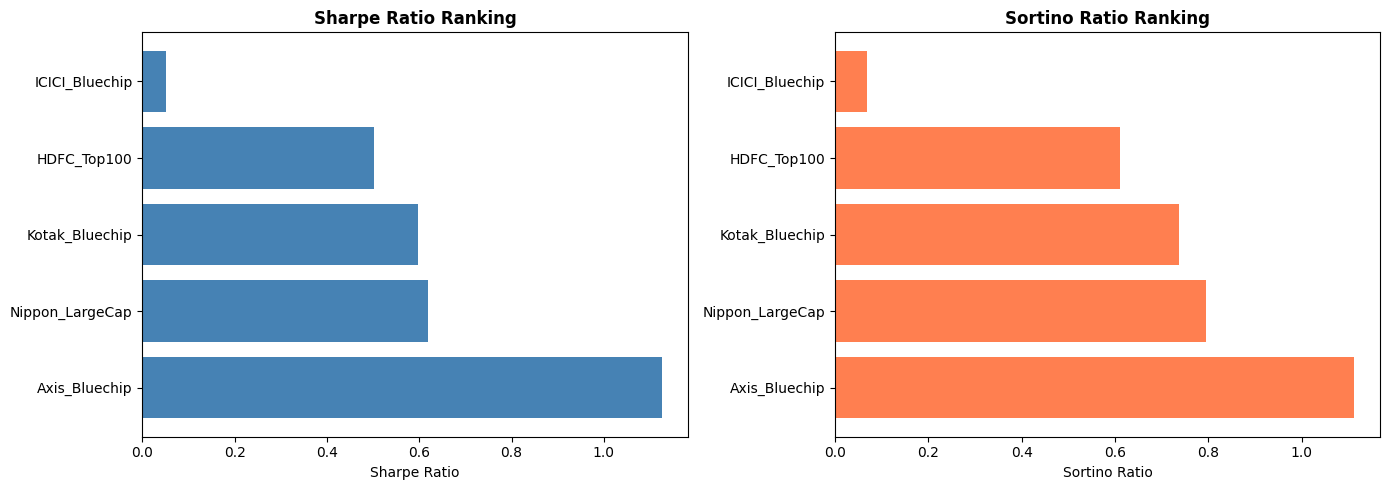

✅ Sharpe & Sortino computed.


In [4]:
# TASK 3 & 4: Sharpe Ratio and Sortino Ratio

Rf_daily = 0.065 / 252  # RBI repo rate proxy — 6.5% annualised

ratio_records = []
for scheme, group in df.groupby("scheme_label"):
    returns = group["daily_return"].dropna()
    
    excess = returns - Rf_daily
    std_all = returns.std()
    downside = returns[returns < 0].std()  # only negative days
    
    sharpe = (excess.mean() / std_all) * np.sqrt(252) if std_all > 0 else np.nan
    sortino = (excess.mean() / downside) * np.sqrt(252) if downside > 0 else np.nan
    
    ratio_records.append({
        "scheme": scheme,
        "Sharpe_Ratio": round(sharpe, 3),
        "Sortino_Ratio": round(sortino, 3),
        "Ann_Return_%": round(returns.mean() * 252 * 100, 2),
        "Ann_Volatility_%": round(std_all * np.sqrt(252) * 100, 2)
    })

ratios_df = pd.DataFrame(ratio_records).sort_values("Sharpe_Ratio", ascending=False)
print("=== Sharpe & Sortino Ranking ===")
print(ratios_df.to_string(index=False))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(ratios_df["scheme"], ratios_df["Sharpe_Ratio"], color="steelblue")
axes[0].set_title("Sharpe Ratio Ranking", fontweight="bold")
axes[0].set_xlabel("Sharpe Ratio")

axes[1].barh(ratios_df["scheme"], ratios_df["Sortino_Ratio"], color="coral")
axes[1].set_title("Sortino Ratio Ranking", fontweight="bold")
axes[1].set_xlabel("Sortino Ratio")

plt.tight_layout()
plt.savefig("charts/sharpe_sortino.png", dpi=150)
plt.show()
print("✅ Sharpe & Sortino computed.")

In [5]:
# TASK 5: Alpha and Beta using OLS regression
# We use Nippon_LargeCap as benchmark proxy (closest to Nifty 100)

benchmark_label = "Nippon_LargeCap"
benchmark_returns = df[df["scheme_label"] == benchmark_label].set_index("date")["daily_return"]

alpha_beta_records = []
for scheme, group in df.groupby("scheme_label"):
    if scheme == benchmark_label:
        continue
    fund_returns = group.set_index("date")["daily_return"]
    
    # Align dates
    combined = pd.concat([fund_returns, benchmark_returns], axis=1).dropna()
    combined.columns = ["fund", "benchmark"]
    
    if len(combined) < 30:
        continue
    
    slope, intercept, r_value, p_value, std_err = stats.linregress(
        combined["benchmark"], combined["fund"]
    )
    
    alpha_annualised = intercept * 252 * 100  # annualised %
    
    alpha_beta_records.append({
        "scheme": scheme,
        "Alpha_%_ann": round(alpha_annualised, 3),
        "Beta": round(slope, 3),
        "R_squared": round(r_value**2, 3)
    })

alpha_beta_df = pd.DataFrame(alpha_beta_records)
print("=== Alpha & Beta Table ===")
print(alpha_beta_df.to_string(index=False))

# Save CSV
alpha_beta_df.to_csv("alpha_beta.csv", index=False)
print("✅ alpha_beta.csv saved.")

=== Alpha & Beta Table ===
        scheme  Alpha_%_ann  Beta  R_squared
 Axis_Bluechip        6.893 0.004      0.016
   HDFC_Top100        1.422 0.795      0.655
ICICI_Bluechip       -6.902 0.934      0.838
Kotak_Bluechip        0.858 1.070      0.719
✅ alpha_beta.csv saved.


=== Maximum Drawdown ===
         scheme  Max_Drawdown_% Worst_Date
 Kotak_Bluechip          -25.95 2025-03-04
 ICICI_Bluechip          -25.11 2022-06-17
    HDFC_Top100          -22.42 2025-03-03
Nippon_LargeCap          -15.37 2025-02-28
  Axis_Bluechip           -0.23 2022-05-06


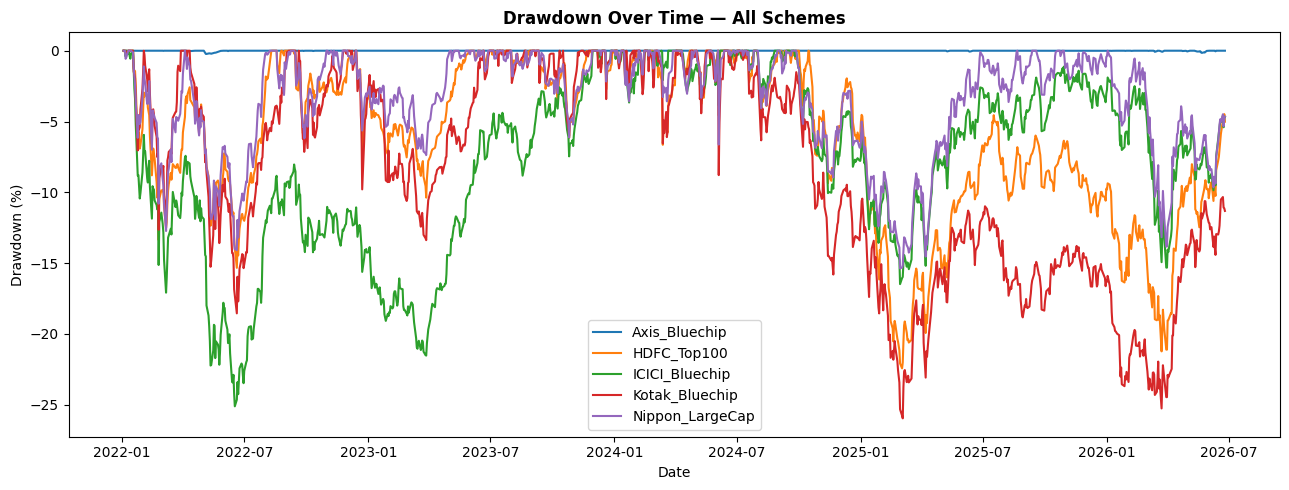

✅ Max Drawdown computed.


In [6]:
# TASK 6: Maximum Drawdown per scheme

drawdown_records = []
for scheme, group in df.groupby("scheme_label"):
    group = group.sort_values("date").copy()
    group["running_max"] = group["nav"].cummax()
    group["drawdown"] = group["nav"] / group["running_max"] - 1
    
    max_dd = group["drawdown"].min()
    max_dd_date = group.loc[group["drawdown"].idxmin(), "date"]
    
    drawdown_records.append({
        "scheme": scheme,
        "Max_Drawdown_%": round(max_dd * 100, 2),
        "Worst_Date": max_dd_date.date()
    })

dd_df = pd.DataFrame(drawdown_records).sort_values("Max_Drawdown_%")
print("=== Maximum Drawdown ===")
print(dd_df.to_string(index=False))

# Plot drawdown over time for all schemes
plt.figure(figsize=(13, 5))
for scheme, group in df.groupby("scheme_label"):
    group = group.sort_values("date").copy()
    group["running_max"] = group["nav"].cummax()
    group["drawdown"] = (group["nav"] / group["running_max"] - 1) * 100
    plt.plot(group["date"], group["drawdown"], label=scheme)

plt.title("Drawdown Over Time — All Schemes", fontweight="bold")
plt.ylabel("Drawdown (%)")
plt.xlabel("Date")
plt.legend()
plt.tight_layout()
plt.savefig("charts/max_drawdown.png", dpi=150)
plt.show()
print("✅ Max Drawdown computed.")

=== Fund Scorecard (0–100) ===
         scheme  CAGR_3yr_%  Sharpe_Ratio  Alpha_%_ann  Max_Drawdown_%  Score
 Kotak_Bluechip       17.46         0.598        0.858          -25.95   78.0
    HDFC_Top100       14.14         0.501        1.422          -22.42   55.0
Nippon_LargeCap       15.46         0.618          NaN          -15.37   54.0
  Axis_Bluechip        7.40         1.125        6.893           -0.23   52.0
 ICICI_Bluechip       11.69         0.052       -6.902          -25.11   41.0


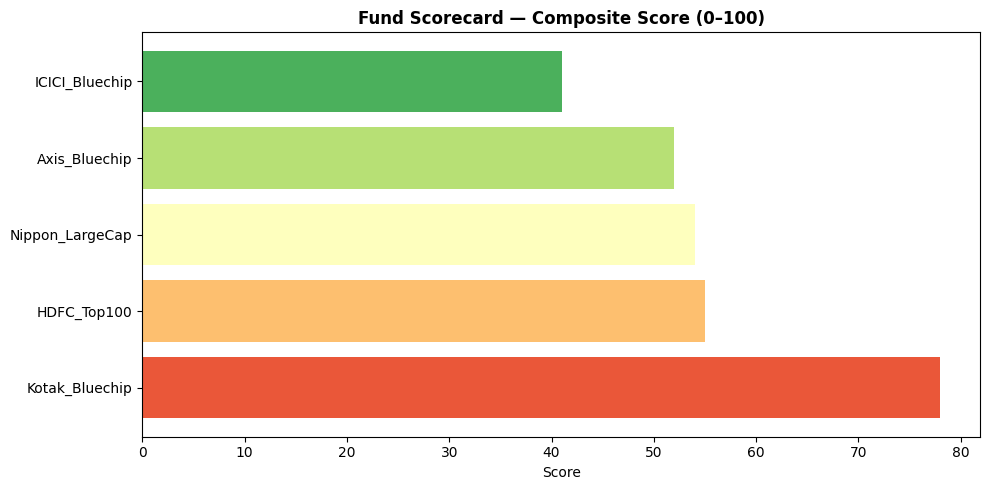

✅ fund_scorecard.csv saved.


In [7]:
# TASK 7: Fund Scorecard (0–100 composite score)

# Merge all metrics
scorecard = cagr_df[["scheme", "CAGR_3yr_%"]].copy()
scorecard = scorecard.merge(ratios_df[["scheme", "Sharpe_Ratio"]], on="scheme")
scorecard = scorecard.merge(alpha_beta_df[["scheme", "Alpha_%_ann"]], on="scheme", how="left")
scorecard = scorecard.merge(dd_df[["scheme", "Max_Drawdown_%"]], on="scheme")

# Rank each metric (higher = better, except drawdown)
scorecard["rank_return"]  = scorecard["CAGR_3yr_%"].rank(ascending=True)
scorecard["rank_sharpe"]  = scorecard["Sharpe_Ratio"].rank(ascending=True)
scorecard["rank_alpha"]   = scorecard["Alpha_%_ann"].rank(ascending=True)
scorecard["rank_dd"]      = scorecard["Max_Drawdown_%"].rank(ascending=False)  # less DD = better

n = len(scorecard)
scorecard["Score"] = (
    0.30 * scorecard["rank_return"] +
    0.25 * scorecard["rank_sharpe"] +
    0.20 * scorecard["rank_alpha"].fillna(0) +
    0.25 * scorecard["rank_dd"]
) / n * 100

scorecard["Score"] = scorecard["Score"].round(1)
scorecard = scorecard.sort_values("Score", ascending=False)

print("=== Fund Scorecard (0–100) ===")
print(scorecard[["scheme","CAGR_3yr_%","Sharpe_Ratio","Alpha_%_ann","Max_Drawdown_%","Score"]].to_string(index=False))

# Save CSV
scorecard.to_csv("fund_scorecard.csv", index=False)

# Bar chart
plt.figure(figsize=(10, 5))
plt.barh(scorecard["scheme"], scorecard["Score"],
         color=sns.color_palette("RdYlGn", len(scorecard)))
plt.title("Fund Scorecard — Composite Score (0–100)", fontweight="bold")
plt.xlabel("Score")
plt.tight_layout()
plt.savefig("charts/fund_scorecard.png", dpi=150)
plt.show()
print("✅ fund_scorecard.csv saved.")

=== Tracking Error vs Benchmark ===
        scheme  Tracking_Error_%
 Axis_Bluechip            13.839
   HDFC_Top100             8.620
ICICI_Bluechip             5.852
Kotak_Bluechip             9.463


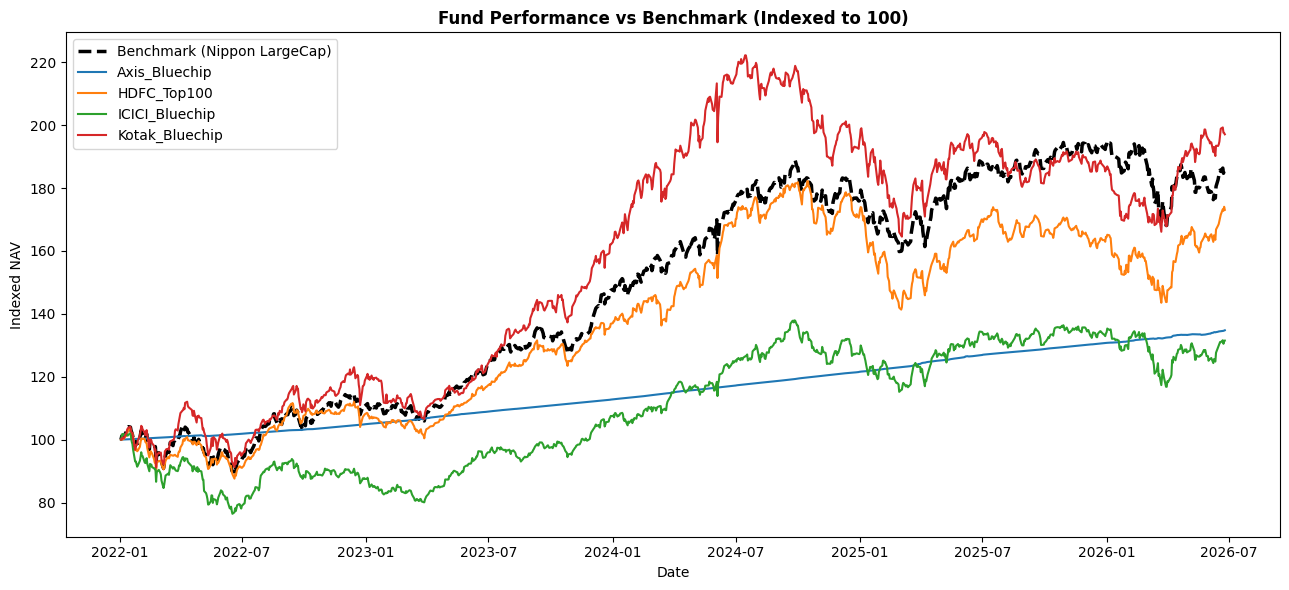

✅ Benchmark comparison chart saved.


In [8]:
# TASK 8: Top funds vs Benchmark + Tracking Error

benchmark_label = "Nippon_LargeCap"
top_funds = [s for s in df["scheme_label"].unique() if s != benchmark_label]

benchmark = df[df["scheme_label"] == benchmark_label][["date","nav"]].copy()
benchmark = benchmark.rename(columns={"nav": "benchmark_nav"})
benchmark["benchmark_return"] = benchmark["benchmark_nav"].pct_change()

plt.figure(figsize=(13, 6))

# Plot benchmark
bm_norm = benchmark.copy()
bm_norm["indexed"] = bm_norm["benchmark_nav"] / bm_norm["benchmark_nav"].iloc[0] * 100
plt.plot(bm_norm["date"], bm_norm["indexed"], label="Benchmark (Nippon LargeCap)",
         linewidth=2.5, linestyle="--", color="black")

te_records = []
for scheme in top_funds:
    fund = df[df["scheme_label"] == scheme][["date","nav"]].copy()
    fund["indexed"] = fund["nav"] / fund["nav"].iloc[0] * 100
    plt.plot(fund["date"], fund["indexed"], label=scheme)
    
    # Tracking error
    fund["fund_return"] = fund["nav"].pct_change()
    combined = fund[["date","fund_return"]].merge(
        benchmark[["date","benchmark_return"]], on="date"
    ).dropna()
    te = (combined["fund_return"] - combined["benchmark_return"]).std() * np.sqrt(252) * 100
    te_records.append({"scheme": scheme, "Tracking_Error_%": round(te, 3)})

te_df = pd.DataFrame(te_records)
print("=== Tracking Error vs Benchmark ===")
print(te_df.to_string(index=False))

plt.title("Fund Performance vs Benchmark (Indexed to 100)", fontweight="bold")
plt.ylabel("Indexed NAV")
plt.xlabel("Date")
plt.legend()
plt.tight_layout()
plt.savefig("charts/benchmark_comparison.png", dpi=150)
plt.show()
print("✅ Benchmark comparison chart saved.")